# **Objective**

The goal of this project is to build a simple AI system that predicts whether an employee is likely to leave the company (attrition).
We will explore the dataset, preprocess it, train classification models, and evaluate them using multiple metrics, with a focus on F1-score because the dataset is imbalanced.

# **1. Data Understanding & Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib
from google.colab import files

**1.1 Load Dataset & Explore**

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

* **Rows**  : 1470
* **Columns**: 36(26numericalcategorical)
* **Target**: Attrition (Yes/No →converted to 1/0 later)






**1.2 Separate Categorical & Numerical Features**

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

**1.3 Visualize Feature Distributions**

We plot both **categorical** and  **numerical** distributions.

In [ ]:
def plot_categorical(df, features):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)
    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.countplot(x=col, data=df,hue=col, legend=False, palette='Set2', order=df[col].value_counts().index)
        plt.xticks(rotation=30, ha='right')
        plt.title(col, fontsize=12)
        plt.tight_layout()

    plt.suptitle('Categorical Features Distribution', fontsize=16, y=1.02)
    plt.show()

# --- Function to plot numerical features ---
def plot_numerical(df, features):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)
    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30, color='skyblue')
        plt.title(col, fontsize=12)
        plt.tight_layout()

    plt.suptitle('Numerical Features Distribution', fontsize=16, y=1.02)
    plt.show()

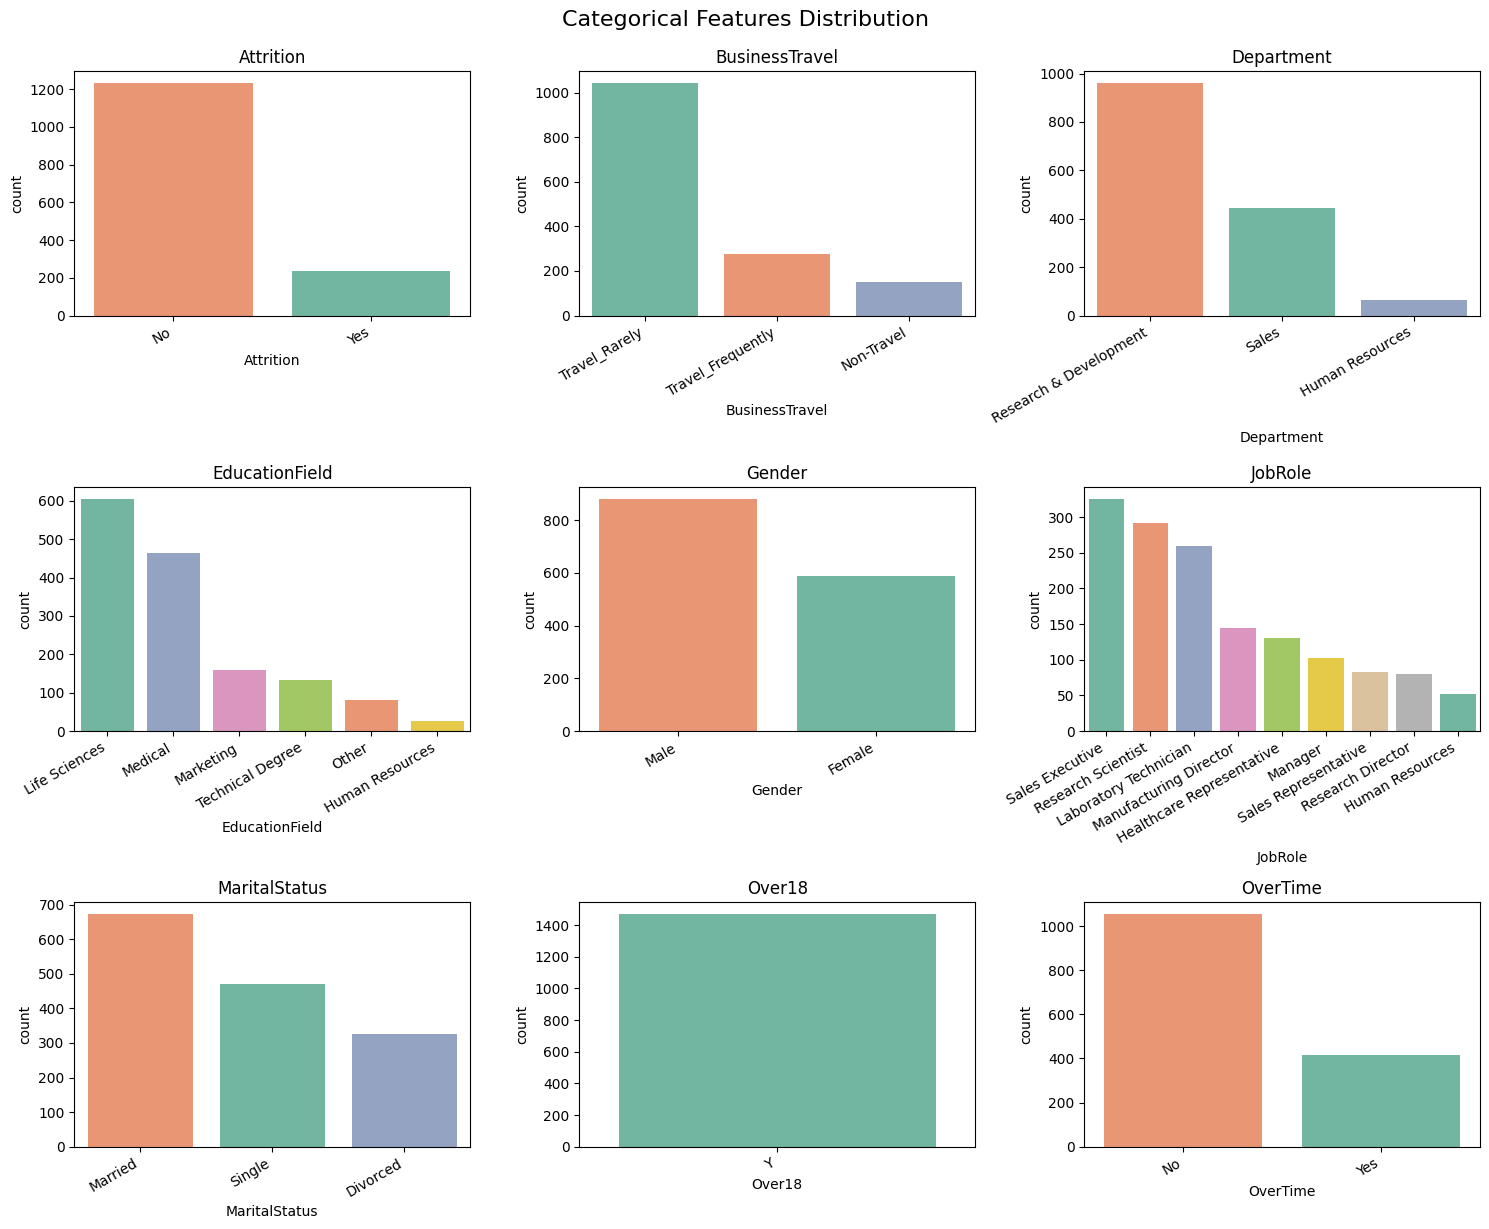

In [ ]:
plot_categorical(df, categorical_features)

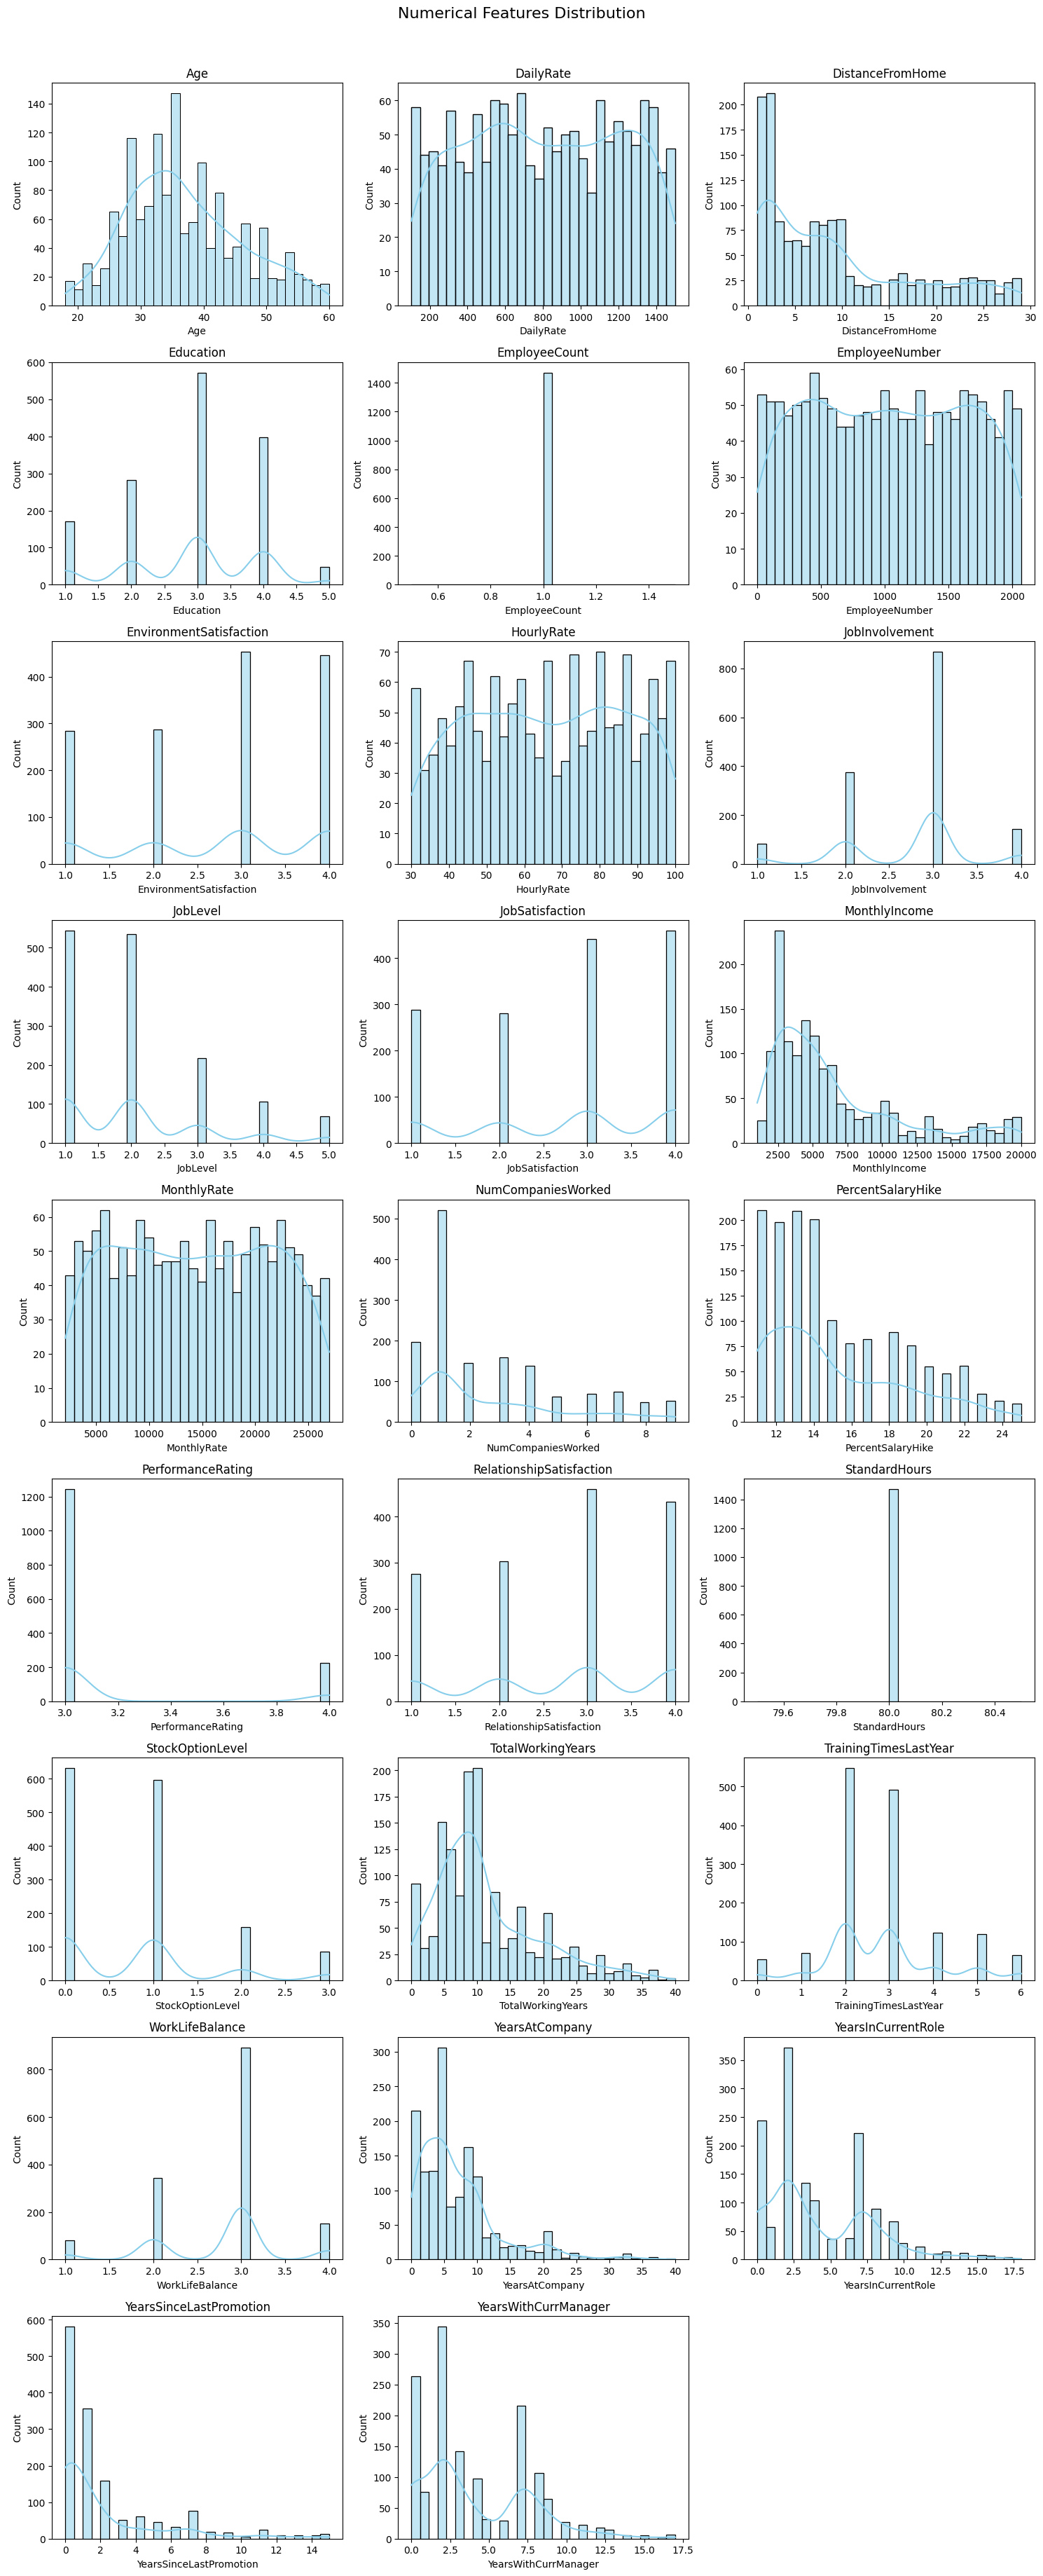

In [ ]:
plot_numerical(df, numerical_features)

**🔍 Additional Meaningful Visualizations**

1. Attrition Rate by Job Role

/tmp/ipython-input-2304694244.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot["Attrition"] = df_plot["Attrition"].replace({"Yes": 1, "No": 0}).infer_objects(copy=False)


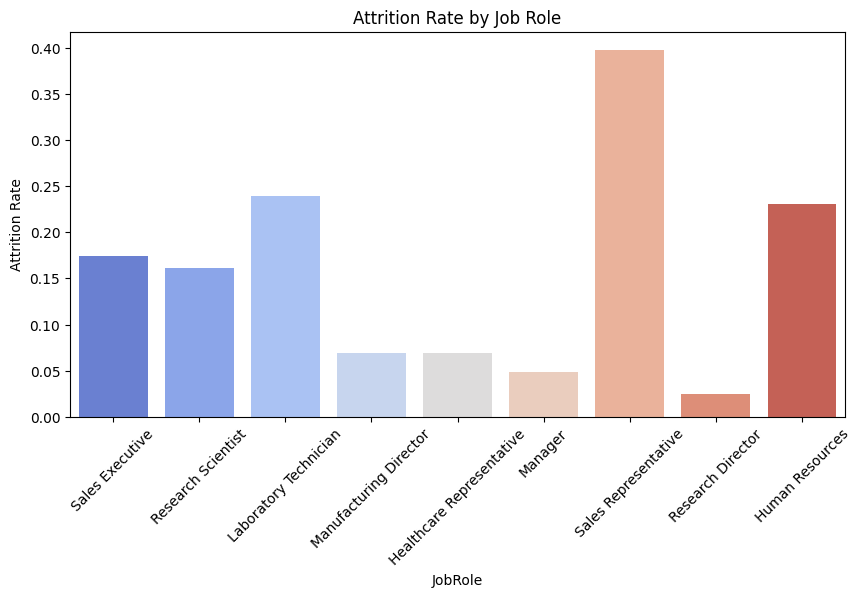

In [ ]:
df_plot = df.copy()
df_plot["Attrition"] = df_plot["Attrition"].replace({"Yes": 1, "No": 0}).infer_objects(copy=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x="JobRole",
    y="Attrition",
    hue="JobRole",            # Assign hue to avoid palette warning
    data=df_plot,
    errorbar=None,            # Replace ci=None
    palette="coolwarm",
    legend=False              # Hide the extra legend from hue
)
plt.xticks(rotation=45)
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate")
plt.show()

Sales Representatives have the highest attrition rate, nearing 40%, followed by Laboratory Technicians and Human Resources roles. In contrast, Research Directors and Managers have the lowest attrition rates, indicating greater job stability in these positions

2. Monthly Income Distribution by Attrition


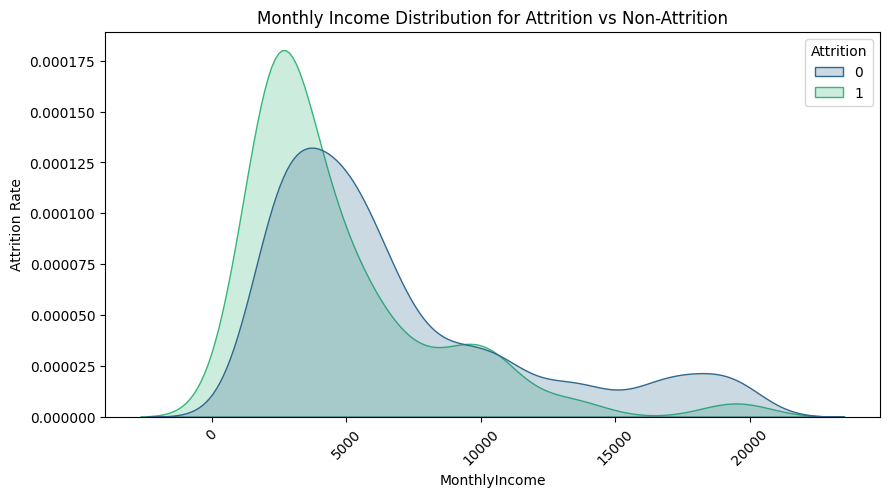

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    x="MonthlyIncome",
    hue="Attrition",            # Assign hue to avoid palette warning
    data=df_plot,
    fill=True, common_norm=False, palette="viridis"              # Hide the extra legend from hue
)
plt.xticks(rotation=45)
plt.title("Monthly Income Distribution for Attrition vs Non-Attrition")
plt.ylabel("Attrition Rate")
plt.show()

Employees with lower monthly incomes, particularly below $5,000, show a noticeably higher attrition rate compared to higher-income groups. As income increases, the likelihood of attrition declines sharply, suggesting that financial incentives may play a key role in retaining employees.

**1.4 Data Cleaning**



*   Dropped irrelevant columns: **Over18, EmployeeCount, StandardHours,EmployeeNumber**

*   Encoded binary categoricals with **LabelEncoder** and multi-class categoricals with **pd.get_dummies**.
*   Removed **outliers** in **MonthlyIncome** using IQR.


*   Scaled numerical features using **MinMaxScaler**.



In [ ]:
df = df.drop(columns=['Over18', 'EmployeeCount', 'StandardHours','EmployeeNumber'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [ ]:
df_encoded = df.copy()

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns
label_enc_cols = [col for col in categorical_features if df[col].nunique() == 2]
le = LabelEncoder()
for col in label_enc_cols:
    df_encoded[col] = le.fit_transform(df[col])

In [ ]:
multi_class_cols = [col for col in categorical_features if df[col].nunique() > 2]
df_encoded = pd.get_dummies(df_encoded, columns=multi_class_cols, drop_first=True)

In [ ]:
df_encoded

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,False,True,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,4,1,42,2,3,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2,1,87,4,2,...,False,False,False,True,False,False,False,False,True,False
1468,49,0,1023,2,3,4,1,63,2,2,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [ ]:
Q1 = df_encoded['MonthlyIncome'].quantile(0.25)
Q3 = df_encoded['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_encoded = df_encoded[(df_encoded['MonthlyIncome'] >= lower_bound) & (df_encoded['MonthlyIncome'] <= upper_bound)]
df_encoded

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,False,True,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,4,1,42,2,3,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2,1,87,4,2,...,False,False,False,True,False,False,False,False,True,False
1468,49,0,1023,2,3,4,1,63,2,2,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
int_cols = df_encoded.select_dtypes(include=['int64']).columns

scaler = MinMaxScaler()
df_encoded[int_cols] = scaler.fit_transform(df_encoded[int_cols])

df_encoded.head()

/tmp/ipython-input-2278491797.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[int_cols] = scaler.fit_transform(df_encoded[int_cols])


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.547619,1.0,0.715820,0.000000,0.25,0.333333,0.0,0.914286,0.666667,0.333333,...,False,False,False,False,False,False,True,False,False,True
1,0.738095,0.0,0.126700,0.250000,0.00,0.666667,1.0,0.442857,0.333333,0.333333,...,False,False,False,False,False,True,False,False,True,False
2,0.452381,1.0,0.909807,0.035714,0.25,1.000000,1.0,0.885714,0.333333,0.000000,...,False,True,False,False,False,False,False,False,False,True
3,0.357143,0.0,0.923407,0.071429,0.75,1.000000,0.0,0.371429,0.666667,0.000000,...,False,False,False,False,False,True,False,False,True,False
4,0.214286,0.0,0.350036,0.035714,0.00,0.000000,1.0,0.142857,0.666667,0.000000,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
df_encoded["Attrition"].value_counts()

,count
Attrition,
0.0,1124
1.0,232


Correlation Heatmap


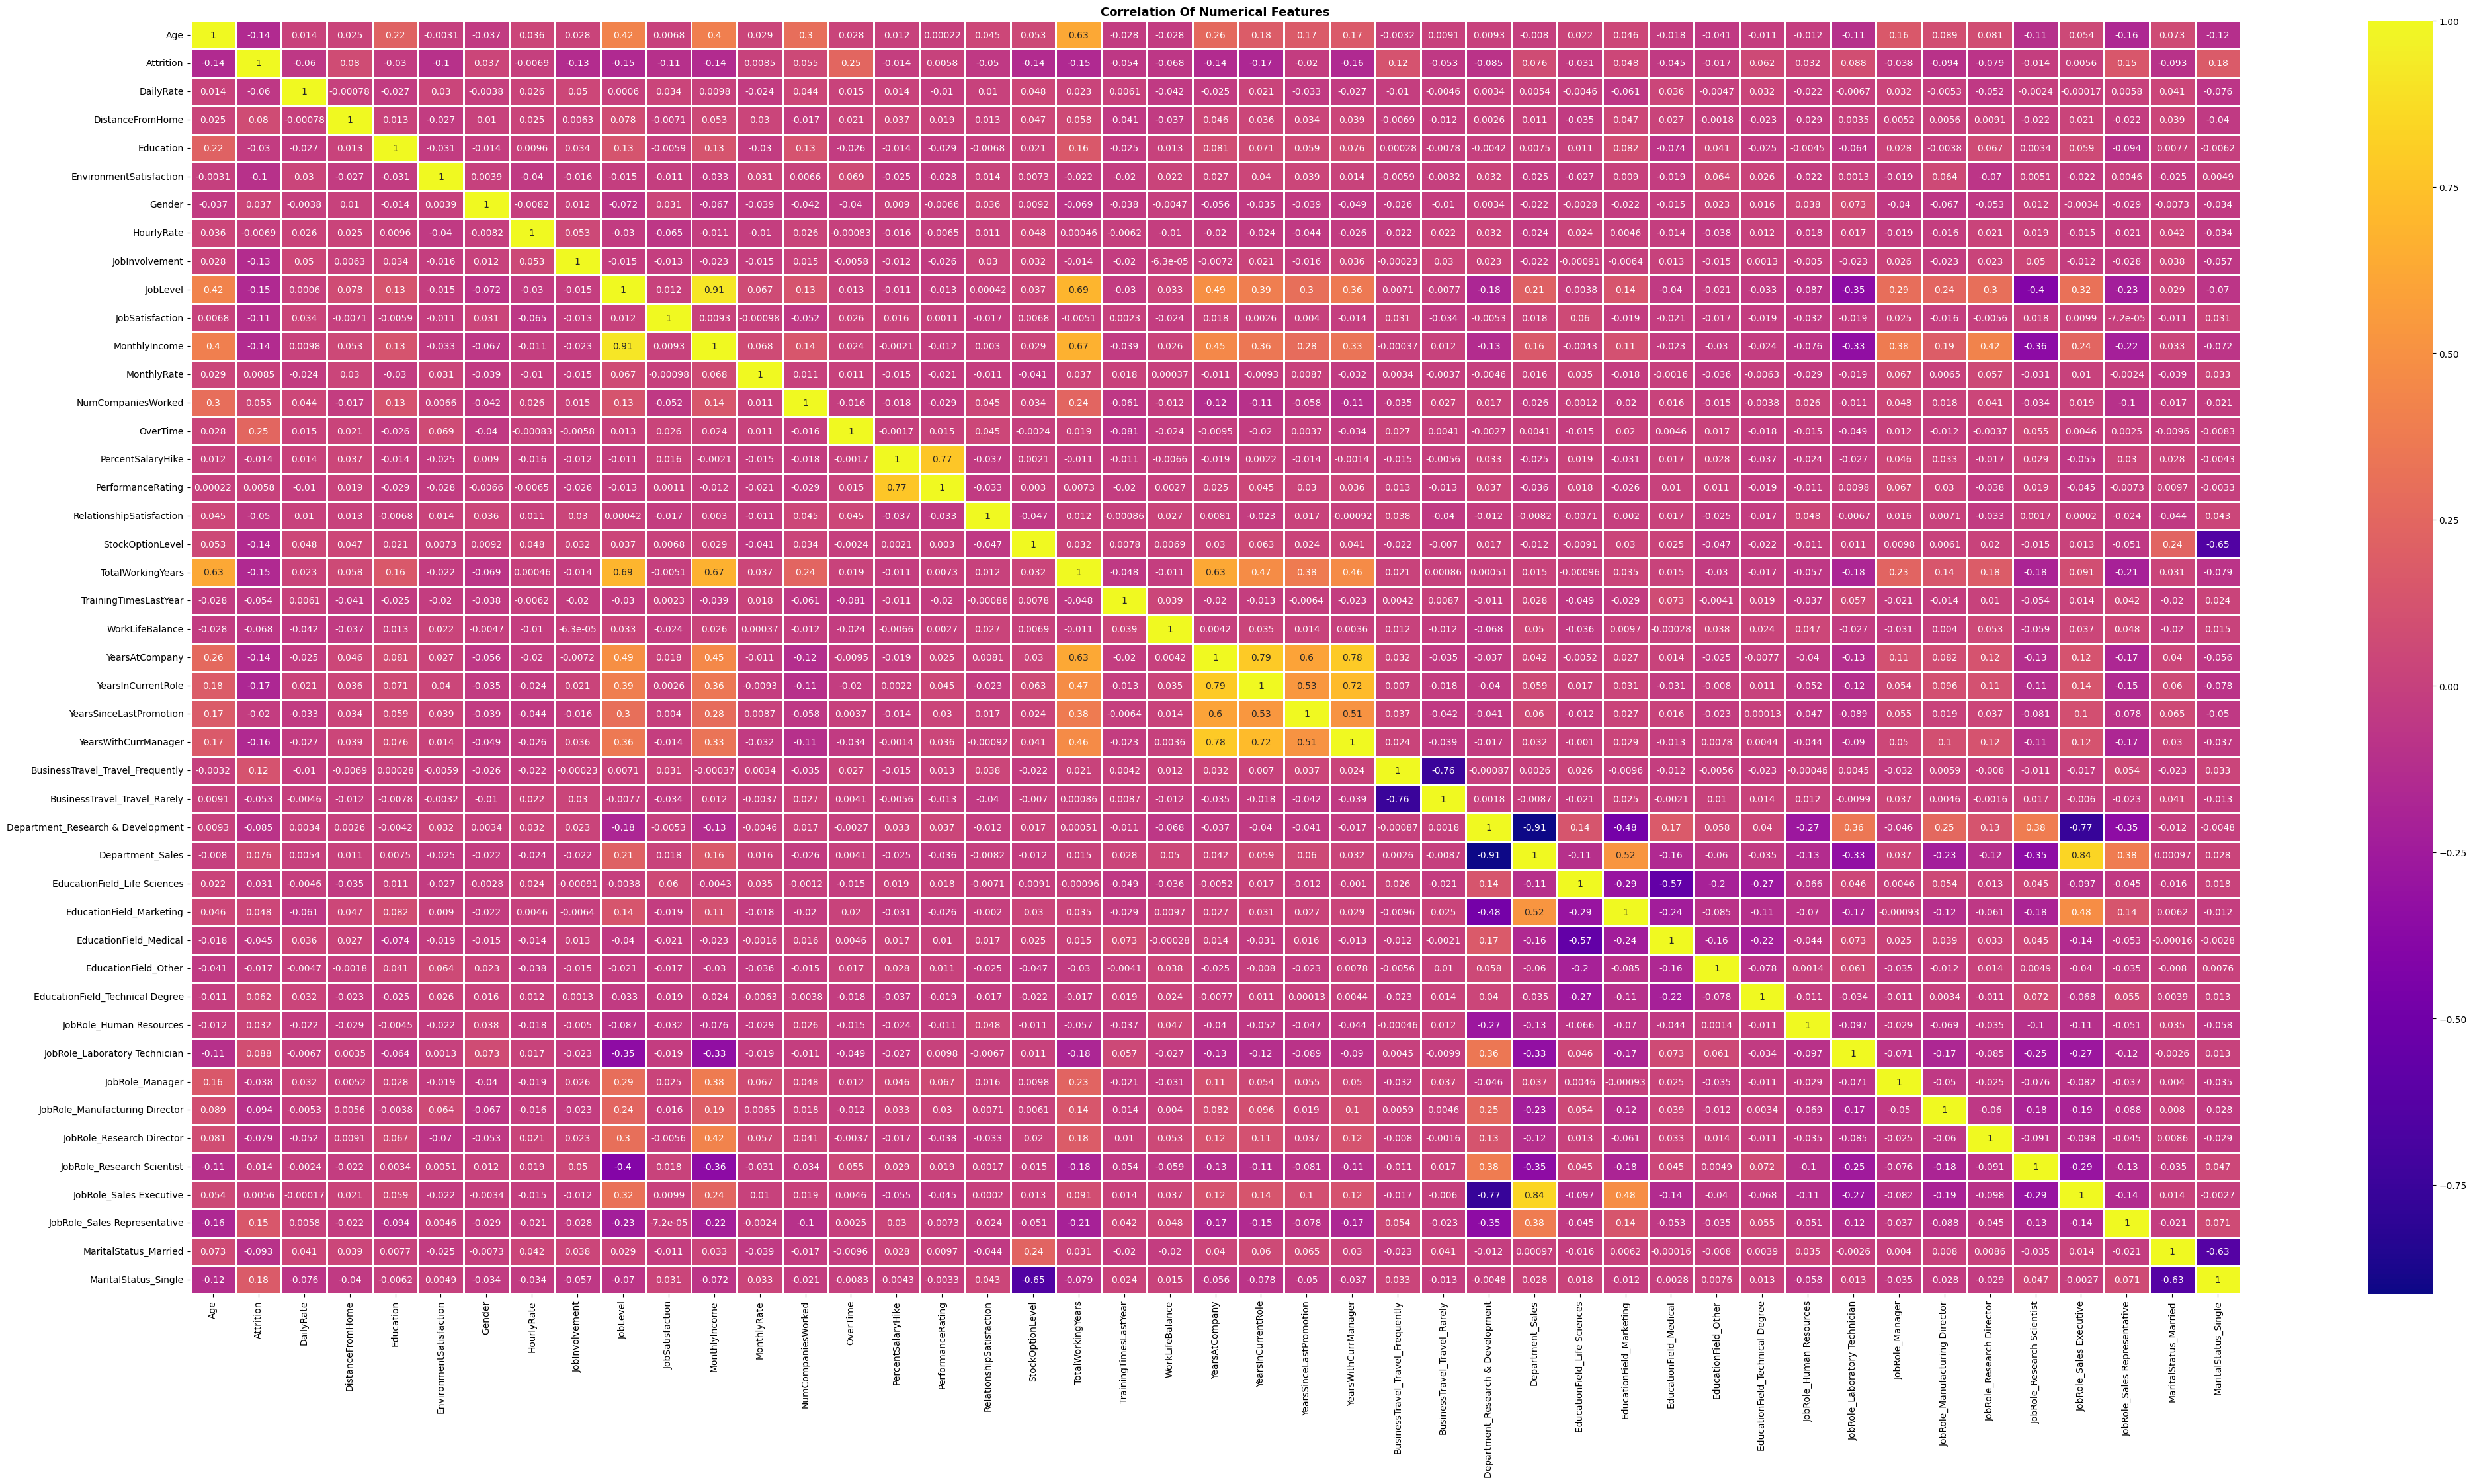

In [ ]:
plt.figure(figsize=(50,25))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='plasma', linewidths=1)
plt.title("Correlation Of Numerical Features", fontsize=13, fontweight='bold')
plt.show()

# **2. Model Building**

**2.1 Train-Test Split**

In [ ]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y,
                                                    random_state=42
                                                    )

In [ ]:
X_train.shape,X_test.shape

((1084, 44), (272, 44))

In [ ]:
y_train.shape,y_test.shape

((1084,), (272,))

**2.2 Model Training & Evaluation**

We test **Logistic Regression, Decision Tree, Random Forest, XGBoost**.

We evaluate **Accuracy, F1-score, ROC-AUC** and show **Confusion Matrices**.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=5.2, eval_metric="logloss", random_state=42)
}

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

results_list = []
predictions = {}
y_labels = sorted(y.unique())  # consistent label order

# Train and evaluate models (metrics only)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    # Store predictions for confusion matrix
    predictions[name] = y_pred

    # Store metrics in a list of dicts
    results_list.append({
        "Model": name,
        "Accuracy": model.score(X_test, y_test),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "F1": classification_report(y_test, y_pred, output_dict=True)[str(y_labels[-1])]["f1-score"]
    })

# Convert to DataFrame
results_df = pd.DataFrame(results_list)
print(results_df)



Logistic Regression
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83       225
         1.0       0.38      0.70      0.49        47

    accuracy                           0.75       272
   macro avg       0.65      0.73      0.66       272
weighted avg       0.83      0.75      0.78       272

ROC-AUC: 0.7685106382978724

Decision Tree
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86       225
         1.0       0.32      0.28      0.30        47

    accuracy                           0.77       272
   macro avg       0.58      0.58      0.58       272
weighted avg       0.76      0.77      0.77       272

ROC-AUC: 0.5760756501182034

Random Forest
              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91       225
         1.0       0.71      0.11      0.19        47

    accuracy                           0.84       272
   macro avg       0.

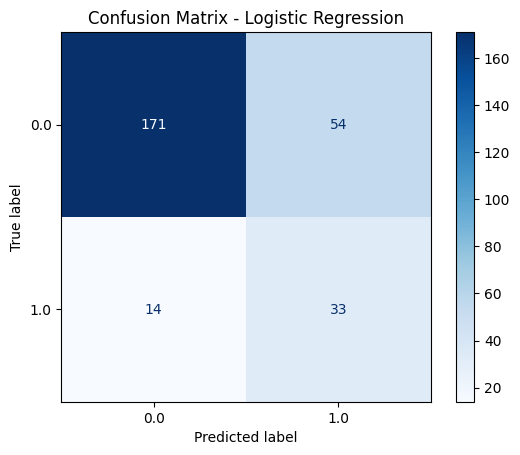

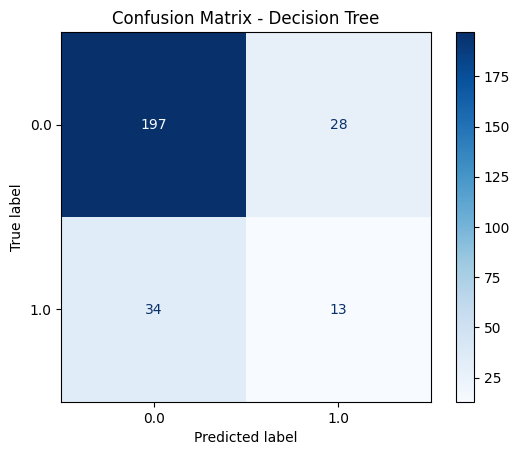

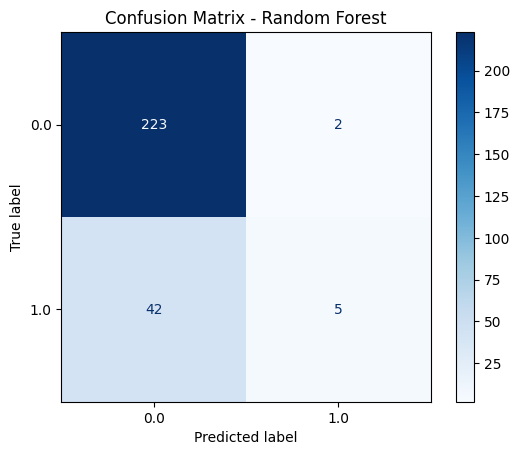

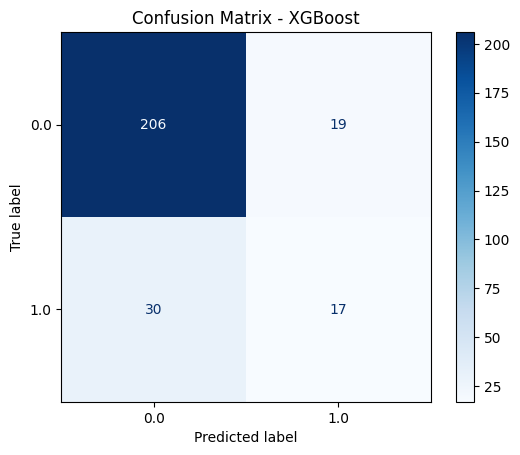

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred, labels=y_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_labels)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


**2.3 Model Performance Comparison**

<Figure size 1000x600 with 0 Axes>

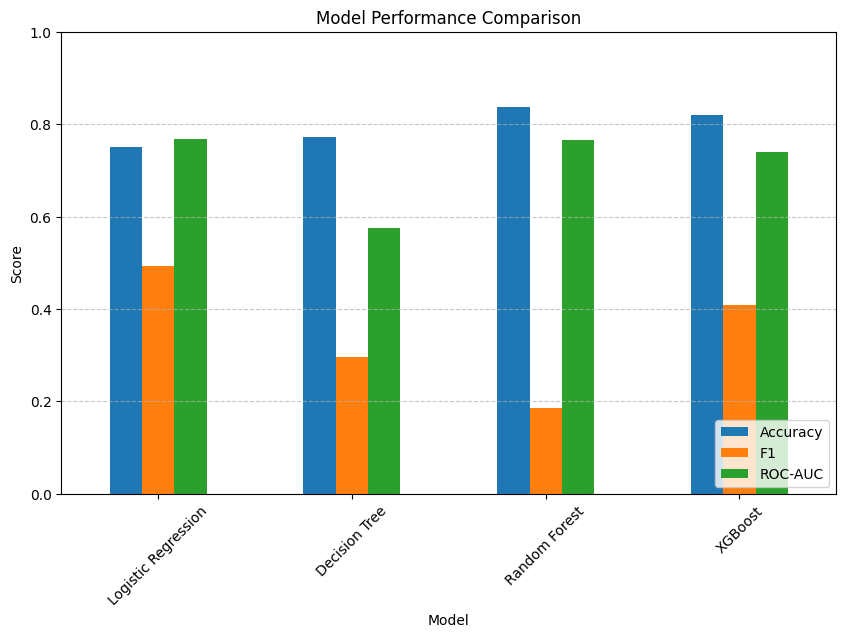

In [ ]:
plt.figure(figsize=(10, 6))
results_df.plot(x="Model", y=["Accuracy", "F1", "ROC-AUC"], kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.show()


Based on the graph, in the next **fine-tuning** phase I will choose **Logistic Regression**, as it achieves the highest **F1** score among all models tested.

# **3. Model Tuning**

We tune **Logistic Regression** with **GridSearchCV**.

In [ ]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
param_grid = [
    # l2 penalty (all solvers)
    {"penalty": ["l2"], "C": [0.01, 0.1, 1, 10],
     "solver": ["liblinear", "saga"], "max_iter": [500]},

    # l1 penalty (liblinear, saga)
    {"penalty": ["l1"], "C": [0.01, 0.1, 1, 10],
     "solver": ["liblinear", "saga"], "max_iter": [500]},

    # elasticnet penalty (only saga)
    {"penalty": ["elasticnet"], "C": [0.01, 0.1, 1, 10],
     "solver": ["saga"], "l1_ratio": [0.5, 0.7], "max_iter": [500]}
]

In [ ]:
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Val ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Val ROC-AUC: 0.8415922626537153


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.84       225
         1.0       0.38      0.70      0.50        47

    accuracy                           0.75       272
   macro avg       0.65      0.73      0.67       272
weighted avg       0.83      0.75      0.78       272

Test ROC-AUC: 0.7676595744680852


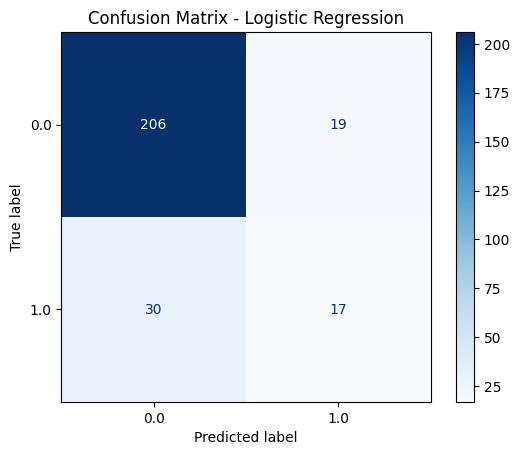

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

I have used an ML model so far, and now I also want to experiment with a neural network model.


# **4. Neural Network Model**

We build a simple Keras model with Early Stopping.

In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weights)

Class Weights: [0.6028921  2.92972973]


In [ ]:
nmodel = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

nmodel.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[]
)

nmodel.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=20,
                           restore_best_weights=True)

In [ ]:
history = nmodel.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6973 - val_loss: 0.6408
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6508 - val_loss: 0.6344
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6364 - val_loss: 0.6155
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6188 - val_loss: 0.5930
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5595 - val_loss: 0.6134
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5758 - val_loss: 0.5257
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6099 - val_loss: 0.5495
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5267 - val_loss: 0.5408
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5237 - val_loss: 0.5634
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5418 - val_loss: 0.4994
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4827 - val_loss: 0.5472
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89       225
         1.0       0.47      0.36      0.41        47

    accuracy                           0.82       272
   macro avg       0.67      0.64      0.65       272
weighted avg       0.80      0.82      0.81       272

F1 Score: 0.40963855421686746
ROC-AUC: 0.6386288416075651


In [62]:
joblib.dump(best_model, "best_model.pkl")
files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

After testing both ML and DL models, I concluded that the Logistic Regression model achieved a **50% F1 score** and delivered the best performance.

Top 5 Features Influencing Job Leaving:
                     Feature  Importance
23  YearsSinceLastPromotion    2.182457
21           YearsAtCompany    1.979928
13                 OverTime    1.826791
22       YearsInCurrentRole    1.699295
12       NumCompaniesWorked    1.566936


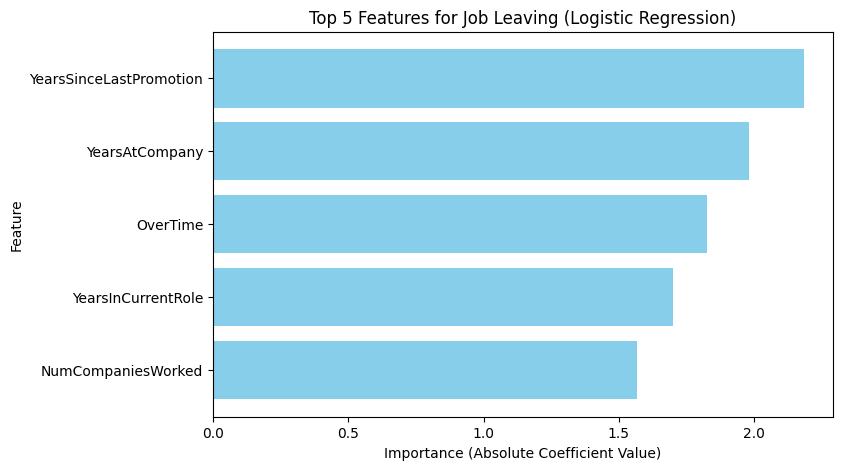

In [ ]:
coef_importance = np.abs(best_model.coef_[0])
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': coef_importance
}).sort_values(by='Importance', ascending=False)

top_5_features = feature_importance_df.head(5)
print("Top 5 Features Influencing Job Leaving:\n", top_5_features)

plt.figure(figsize=(8, 5))
plt.barh(top_5_features['Feature'], top_5_features['Importance'], color='skyblue')
plt.xlabel("Importance (Absolute Coefficient Value)")
plt.ylabel("Feature")
plt.title("Top 5 Features for Job Leaving (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

Based on the feature importance chart from the logistic regression model, the top factors influencing job leaving are:


1.   OverTime – Employees working frequent overtime are significantly more
likely to leave, indicating burnout and work-life imbalance.
2.   Age – Younger employees (especially early in their careers) tend to switch jobs more often, possibly for higher pay or career growth.
3.   JobRole – Certain roles have higher turnover, potentially due to job stress, skill mismatch, or limited advancement opportunities.
4.   MonthlyIncome – Lower-paid employees are more prone to leaving, suggesting dissatisfaction with compensation.
5.   DistanceFromHome – Longer commute distances correlate with higher attrition, likely due to time and travel stress.
Suggestions to Reduce Employee Attrition


1.Address Work-Life Balance
*   Limit excessive overtime and implement flexible work hours or hybrid     options.
*   Monitor workload distribution to avoid employee burnout.
2.Career Development Programs
*   Offer clear growth paths, mentorship, and training to keep younger employees engaged.
*   Provide skill-based certifications and internal promotion opportunities.
3.Review Compensation Structure
*   Benchmark salaries against industry standards.
*   Introduce performance bonuses and retention incentives.
4.Targeted Retention for High-Turnover Roles
*   Conduct role-specific satisfaction surveys.
*   Improve job design or redistribute responsibilities in high-stress positions.
5.Reduce Commute Stress
*   Offer remote work or satellite office options.
*   Provide transport allowances or flexible start/end times.